Do population decoding from a super-subject population, pooling together based on a priori functional properties / morphology / etc.

In [1]:
import itertools
from pathlib import Path
import re
from typing import Literal

from matplotlib.colors import CenteredNorm
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import pickle
from scipy.stats import ttest_ind
import seaborn as sns
import torch
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import make_pipeline

from src.data import get_electrode_df
from src.stimuli import POD_dict

In [2]:
window_size = 0.1
stride = 0.05
pca_num_components = None  # 0.95
outdir = "."

num_control_samples = 10

roi_filters = {
    "stg": ["superiortemporal"],
    "mtg": ["middletemporal"],
    "precentral": ["precentral"],
    "postcentral": ["postcentral"],
    "smg": ["supramarginal"],
}

elec_condition_filters = {
    "stack": [
        ("EC243", 102, "bm"),
        ("EC260", 219, "bm"),
        ("EC243", 103, "bm"),
        ("EC243", 103, "pb"),
        ("EC260", 222, "pb"),
        ("EC243", 105, "bm"),
        ("EC260", 220, "pb"),
        ("EC279", 6, "dn"),
        ("EC248", 365, "dn"),
        ("EC253", 196, "dn"),
        ("EC253", 2, "dn"),
        ("EC279", 167, "dn"),
        ("EC287", 59, "dn"),
        ("EC279", 4, "bm"),
        ("EC279", 4, "dn"),
        ("EC278", 27, "bm"),
        ("EC260", 206, "bm"),
        ("EC260", 206, "pb"),
        ("EC278", 90, "dn"),
    ],

    "alligator": [
        ("EC243", 102, "dn"),
        ("EC243", 102, "pb"),
        ("EC260", 204, "dn"),
        ("EC260", 91, "dn"),
        ("EC260", 93, "dn"),
        ("EC243", 197, "bm"),
        ("EC260", 109, "dn"),
        ("EC243", 103, "dn"),
        ("EC278", 121, "bm"),
        ("EC260", 92, "dn"),
        ("EC250", 216, "pb"),
        ("EC243", 213, "dn"),
        ("EC248", 364, "dn"),
        ("EC250", 207, "dn"),
        ("EC248", 253, "dn"),
        ("EC282", 97, "dn"),
        ("EC278", 27, "dn"),
        ("EC282", 115, "pb"),
        ("EC278", 90, "pb"),
        ("EC279", 76, "bm"),
    ],

    "loo": [
        ('EC260', 204, 'dn'),
        ('EC260', 204, 'pb'),
        ('EC260', 91, 'bm'),
        ('EC260', 93, 'pb'),
        ('EC243', 197, 'dn'),
        ('EC260', 219, 'bm'),
        ('EC260', 219, 'dn'),
        ('EC278', 121, 'dn'),
        ('EC243', 119, 'bm'),
        ('EC243', 119, 'dn'),
        ('EC260', 222, 'bm'),
        ('EC260', 222, 'dn'),
        ('EC243', 105, 'pb'),
        ('EC260', 92, 'bm'),
        ('EC250', 216, 'bm'),
        ('EC260', 221, 'dn'),
        ('EC260', 221, 'pb'),
        ('EC248', 381, 'dn'),
        ('EC260', 220, 'dn'),
        ('EC253', 212, 'dn'),
        ('EC250', 215, 'bm'),
        ('EC250', 215, 'dn'),
        ('EC248', 364, 'bm'),
        ('EC260', 76, 'bm'),
        ('EC260', 76, 'dn'),
        ('EC270', 122, 'dn'),
        ('EC282', 116, 'bm'),
        ('EC287', 124, 'pb'),
        ('EC253', 196, 'pb'),
        ('EC248', 253, 'dn'),
        ('EC279', 167, 'pb'),
        ('EC279', 152, 'dn'),
        ('EC279', 152, 'pb'),
        ('EC287', 5, 'pb'),
        ('EC270', 140, 'dn'),
        ('EC260', 206, 'dn'),
        ('EC278', 90, 'bm'),
        ('EC243', 228, 'dn'),
        ('EC243', 72, 'bm'),
        ('EC243', 72, 'dn'),
        ('EC279', 11, 'pb'),
        ('EC279', 76, 'dn'),
    ]
}



In [3]:
all_epoch_paths = list(Path("outputs/epochs_preprocessed").glob("*.fif"))

In [4]:
epochs = {}
for path in tqdm(all_epoch_paths):
    subject_name = re.findall("(EC[\d]+)_epo", str(path))[0]
    epochs[subject_name] = mne.read_epochs(str(path)).pick("ecog").resample(100)

  0%|          | 0/10 [00:00<?, ?it/s]

Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC279_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -200.00 ...     990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
864 matching events found
No baseline correction applied
0 projection items activated
Sampling frequency of the instance is already 100.0, returning unmodified.
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC243_epo.fif ...
    Reading extended channel information
Isotrak not found
    Found the data of interest:
        t =    -200.00 ...     990.00 ms
        0 CTF compensation matrices available
Adding metadata with 71 columns
864 matching events found
No baseline correction applied
0 projection items activated
Sampling frequency of the instance is already 100.0, returning unmodified.
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC260_epo.fif ...
Isotrak not found
    F

In [5]:
electrode_df = pd.concat([get_electrode_df(subject_name) for subject_name in epochs.keys()],
                         keys=epochs.keys(), names=["subject"])
electrode_df["roi"] = electrode_df.roi.astype(str)
electrode_df = electrode_df.droplevel("electrode_name")

# Drop electrodes metadata which don't have corresponding data
for subject, epochs_i in epochs.items():
    electrode_df.loc[subject, "keep"] = np.arange(len(electrode_df.loc[subject])) < len(epochs_i.info["ch_names"])
electrode_df = electrode_df[electrode_df["keep"]].drop(columns="keep")

electrode_df

long_name  type               roi
subject electrode_idx                                     
EC279   0                Temporal1  grid    middletemporal
        1                Temporal2  grid    middletemporal
        2                Temporal3  grid    middletemporal
        3                Temporal4  grid    middletemporal
        4                Temporal5  grid  superiortemporal
...                            ...   ...               ...
EC250   251            Inferior124  grid     supramarginal
        252            Inferior125  grid     supramarginal
        253            Inferior126  grid  superiortemporal
        254            Inferior127  grid     supramarginal
        255            Inferior128  grid     supramarginal

[2460 rows x 3 columns]

## Find speech-responsive electrodes

In [6]:
# power threshold relative to pre-speech baseline which defines a "speech responsive" electrode
# if we see absolute value change >= this threshold, call the electrode speech-responsive
speech_responsive_threshold = 0.3

Applying baseline correction (mode: mean)


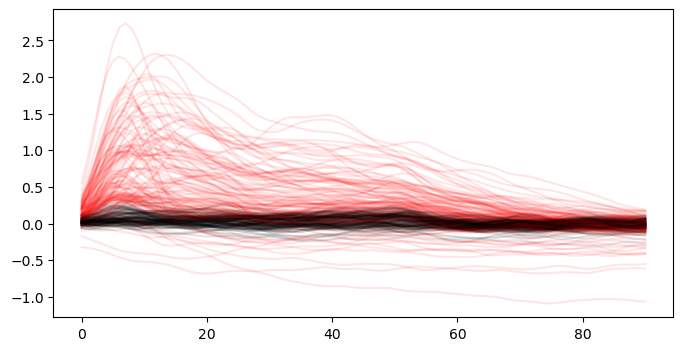

In [7]:
# demo this
dd = next(iter(epochs.values())).copy().apply_baseline((None, 0)).average().crop(tmin=0, tmax=0.9).get_data()
keep = np.abs(dd).max(axis=1) > speech_responsive_threshold

f, ax = plt.subplots(figsize=(8, 4))
for line, k in zip(dd, keep):
    plt.plot(line, color="r" if k else "k", alpha=0.1)

In [8]:
for subject, epochs_i in epochs.items():
    epochs_i = epochs_i.copy().apply_baseline((None, 0)).average().crop(tmin=0, tmax=0.9).get_data()
    assert epochs_i.ndim == 2
    speech_responsive_i = np.abs(epochs_i).max(axis=1) > speech_responsive_threshold

    if len(speech_responsive_i) > len(electrode_df.loc[subject]):
        speech_responsive_i = speech_responsive_i[:len(electrode_df.loc[subject])]
    electrode_df.loc[subject, "speech_responsive"] = speech_responsive_i

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


## Prepare control populations

In [9]:
# add size-matched, subject-matched random samples from STG.
# no control sample should ever contain a site from any of the target samples
avoid_sites = sorted(itertools.chain.from_iterable(elec_condition_filters.values()))
avoid_sites = {subj: set(electrode_idx for _, electrode_idx, _ in xs) for subj, xs in itertools.groupby(avoid_sites, key=lambda x: x[0])}

for elec_condition_filter, filter_set in list(elec_condition_filters.items()):
    filter_set = pd.DataFrame(filter_set, columns=["subject", "electrode_idx", "phoneme_pair"])
    control_sets = [[] for _ in range(num_control_samples)]
    for subject, filter_elecs in filter_set.groupby("subject"):
        # pick matched amount of electrodes from STG
        stg_elecs = electrode_df.query("roi == 'superiortemporal' and subject == @subject and speech_responsive == True")
        stg_elecs = stg_elecs[~stg_elecs.index.get_level_values("electrode_idx").isin(avoid_sites[subject])]
        for i in range(num_control_samples):
            stg_elecs = stg_elecs.sample(n=len(filter_elecs))
            stg_elecs["phoneme_pair"] = filter_elecs.phoneme_pair.values
            control_sets[i].append(stg_elecs.set_index("phoneme_pair", append=True).index.tolist())
    
    for i in range(num_control_samples):
        elec_condition_filters[f"{elec_condition_filter}-stg_control-{i}"] = list(itertools.chain.from_iterable(control_sets[i]))

In [78]:
def run_decoding_analysis(epochs, stride, window_size, elec_filter=None):
    global_tmin = min([epoch.times.min() for epoch in epochs.values()])
    global_tmax = max([epoch.times.max() for epoch in epochs.values()])
    windows_left = np.arange(global_tmin, global_tmax, stride)
    windows_right = np.minimum(global_tmax, windows_left + window_size)
    windows = list(zip(windows_left, windows_right))

    # `outcomes` stores prediction outcomes for each epoch under the optimal model
    outcomes = {}
    # `test_scores` stores cross-validated estimates of held-out generalization
    test_scores = {}
    phoneme_pairs = next(iter(epochs.values())).metadata.phoneme_pair.unique()

    i = 0
    for phoneme_pair, (tmin, tmax), subject_name in tqdm(list(itertools.product(phoneme_pairs, windows, epochs))):
        electrodes_i = electrode_df.loc[subject_name]

        if elec_filter is not None:
            try:
                electrodes_i = pd.merge(
                    pd.DataFrame(elec_filter, columns=["subject", "electrode_idx"]),
                    electrodes_i.reset_index(),
                    on=["subject", "electrode_idx"],
                )
            except KeyError:
                raise

        electrodes_i = electrodes_i.index.get_level_values("electrode_idx")
        if len(electrodes_i) == 0:
            continue

        epochs_i = epochs[subject_name][f"phoneme_pair == '{phoneme_pair}'"].copy()
        pick_electrodes = list(set(electrodes_i) & set(range(len(epochs_i.ch_names))))

        epochs_i = epochs_i.pick(pick_electrodes).crop(tmin, tmax)
        if len(epochs_i) == 0:
            continue

        # epochs * channels * time
        X = epochs_i.get_data()
        X = X.reshape(X.shape[0], -1)

        y = epochs_i.metadata.word_end.str[0] == epochs_i.metadata.phoneme_pair.str[0]
        step = epochs_i.metadata.resampled

        cv_inner = StratifiedKFold(3, shuffle=True)
        cv_outer = StratifiedKFold(3, shuffle=True)

        pipeline = [StandardScaler()]
        if pca_num_components is not None:
            pipeline.append(PCA(n_components=pca_num_components))
        pipeline.append(LogisticRegressionCV(Cs=10, cv=cv_inner, max_iter=1000))
        model = make_pipeline(*pipeline)
        fitted = cross_validate(model, X, y, cv=cv_outer, scoring="roc_auc", return_estimator=True)

        test_scores[subject_name, phoneme_pair, tmin, tmax] = fitted["test_score"]

        outcomes[subject_name, phoneme_pair, tmin, tmax] = pd.concat({
            fold: pd.DataFrame({"decoder_target": y,
                                "decoder_prediction": estimator.predict(X),
                                "decoder_proba": estimator.predict_proba(X)[:, 1]},
                            index=epochs_i.metadata.index.rename("epoch_idx"))
            for fold, estimator in enumerate(fitted["estimator"])
        }, names=["fold"], keys=range(len(fitted["estimator"])))

    return test_scores, outcomes

In [10]:
def run_decoding_analysis_super_subject(epochs, stride, window_size, elec_condition_filter=None,
                                        alignment_strategy: Literal["subsample", "mean"] = "subsample"):
    global_tmin = min([epoch.times.min() for epoch in epochs.values()])
    global_tmax = max([epoch.times.max() for epoch in epochs.values()])
    windows_left = np.arange(global_tmin, global_tmax, stride)
    windows_right = np.minimum(global_tmax, windows_left + window_size)
    windows = list(zip(windows_left, windows_right))

    # `features` stores a df representation of the feature input matrix
    # each row is a feature source with columns `subject`, `electrode_idx`, `time`
    features = {}
    # `outcomes` stores prediction outcomes for each epoch under the optimal model
    outcomes = {}
    # `test_scores` stores cross-validated estimates of held-out generalization
    test_scores = {}
    # `models` stores the fitted models
    models = {}

    phoneme_pairs = next(iter(epochs.values())).metadata.phoneme_pair.unique()

    if elec_condition_filter is not None:
        electrodes = pd.merge(
            pd.DataFrame(elec_condition_filter, columns=["subject", "electrode_idx", "phoneme_pair"]),
            electrode_df.reset_index(),
            on=["subject", "electrode_idx"],
        )
    if len(electrodes) == 0:
        return
    electrodes = electrodes.groupby(["subject", "phoneme_pair"])

    # Prepare to subsample epochs to have the same number of trials across epochs per phoneme pair.
    min_n_trials = min(epochs_i.metadata.groupby(["phoneme_pair", "resampled", "word_end"]).size().min()
                       for epochs_i in epochs.values())
    # TODO alternative would be to take means within-subject
    
    for phoneme_pair, (tmin, tmax) in tqdm(list(itertools.product(phoneme_pairs, windows))):
        X, features_i, metadata = [], [], []
        for subject, epochs_i in epochs.items():
            # subset electrodes
            try:
                electrodes_ij = electrodes.get_group((subject, phoneme_pair))
            except KeyError:
                continue
            epochs_ij = epochs_i[f"phoneme_pair == '{phoneme_pair}'"].copy() \
                .pick(electrodes_ij.electrode_idx).crop(tmin, tmax)
            
            # subset epochs
            if alignment_strategy == "subsample":
                # Subsample and reorder to be consistent across subjects
                # NB indexing needs to happen by integer index in the above now-filtered
                # epochs, so reset index before doing work below
                keep_epoch_idxs = epochs_ij.metadata.reset_index() \
                    .groupby(["resampled", "word_end"]).sample(min_n_trials) \
                    .sort_values(["resampled", "word_end"]).index
                epochs_ij = epochs_ij[keep_epoch_idxs]
            elif alignment_strategy == "mean":
                # Take mean across equivalent trials
                raise NotImplementedError()

            if len(epochs_ij) == 0:
                continue

            X.append(epochs_ij.get_data().reshape(len(epochs_ij), -1))
            features_i.extend([(elec.subject, elec.electrode_idx, tmin + time)
                               for _, elec in electrodes_ij.iterrows()
                               for time in epochs_ij.times])
            metadata.append(epochs_ij.metadata)

        if len(X) == 0:
            continue
        X = np.concatenate(X, axis=1)

        features_i = pd.DataFrame(features_i, columns=["subject", "electrode_idx", "time"])
        assert len(features_i) == X.shape[1]
        
        # make sure trials are properly lined up
        for metadata_i in metadata[1:]:
            assert (metadata[0][["resampled", "word_end"]].values == metadata_i[["resampled", "word_end"]].values).all()
        y = metadata[0].word_end.str[0] == phoneme_pair[0]

        ####

        cv_inner = StratifiedKFold(3, shuffle=True)
        cv_outer = StratifiedKFold(3, shuffle=True)

        pipeline = [StandardScaler()]
        if pca_num_components is not None:
            pipeline.append(PCA(n_components=pca_num_components))

        Cs = np.logspace(-10, 6, 10)
        pipeline.append(LogisticRegressionCV(Cs=Cs, cv=cv_inner, max_iter=1000))
        model = make_pipeline(*pipeline)
        fitted = cross_validate(model, X, y, cv=cv_outer, scoring="roc_auc", return_estimator=True)

        test_scores[phoneme_pair, tmin, tmax] = fitted["test_score"]

        outcomes[phoneme_pair, tmin, tmax] = pd.concat({
            fold: pd.DataFrame({"decoder_target": y,
                                "decoder_prediction": estimator.predict(X),
                                "decoder_proba": estimator.predict_proba(X)[:, 1]},
                            index=range(len(y)))
            for fold, estimator in enumerate(fitted["estimator"])
        }, names=["fold"], keys=range(len(fitted["estimator"])))

        features[phoneme_pair, tmin, tmax] = features_i
        models[phoneme_pair, tmin, tmax] = fitted["estimator"]

    return test_scores, outcomes, models, features

In [11]:
decoding_kwargs = dict(stride=stride, window_size=window_size)
all_scores, all_outcomes, all_models, all_features = {}, {}, {}, {}

In [12]:
scores_all_elecs, outcomes_all_elecs = run_decoding_analysis(epochs, **decoding_kwargs)
all_scores["*"] = scores_all_elecs
all_outcomes["*"] = outcomes_all_elecs

NameError: name 'run_decoding_analysis' is not defined

In [ ]:
for name, elec_condition_filter in tqdm(elec_condition_filters.items(), unit="filter"):
    print(name)
    all_scores[name], all_outcomes[name], all_models[name], all_features[name] = \
        run_decoding_analysis_super_subject(epochs, elec_condition_filter=elec_condition_filter, **decoding_kwargs)

  0%|          | 0/33 [00:00<?, ?filter/s]

stack


  0%|          | 0/72 [00:00<?, ?it/s]

In [153]:
scores_df = pd.concat(
    {filter: pd.concat(
        {key: pd.Series(scores_i).rename("roc_auc") for key, scores_i in scores.items()},
        names=["phoneme_pair", "tmin", "tmax", "fold"])
     for filter, scores in all_scores.items()},
    names=["filter"])
scores_df

filter             phoneme_pair  tmin  tmax  fold
stack              bm            0.00  0.10  0       0.421875
                                             1       0.612847
                                             2       0.536458
                                 0.05  0.15  0       0.559028
                                             1       0.493056
                                                       ...   
loo-stg_control-9  pb            0.90  0.99  1       0.583333
                                             2       0.524306
                                 0.95  0.99  0       0.465278
                                             1       0.321181
                                             2       0.505208
Name: roc_auc, Length: 5940, dtype: float64

In [154]:
hparam_df = pd.DataFrame(
    [{"filter": filter_name, "phoneme_pair": phoneme_pair,
      "tmin": tmin, "tmax": tmax, "fold": j,
      "C": fold_fit.steps[-1][1].C_[0]}
     for filter_name, filter_fits in all_models.items()
     for (phoneme_pair, tmin, tmax), fitted_i in filter_fits.items()
     for j, fold_fit in enumerate(fitted_i)])
hparam_df["t_center"] = (hparam_df.tmin + hparam_df.tmax) / 2
hparam_df = hparam_df.set_index(["filter", "phoneme_pair", "tmin", "tmax"])
hparam_df

fold             C  t_center
filter            phoneme_pair tmin tmax                              
stack             bm           0.00 0.10     0  1.291550e-03     0.050
                                    0.10     1  1.000000e+06     0.050
                                    0.10     2  2.782559e+02     0.050
                               0.05 0.15     0  1.668101e+04     0.100
                                    0.15     1  2.782559e+02     0.100
...                                        ...           ...       ...
loo-stg_control-9 pb           0.90 0.99     1  7.742637e-02     0.945
                                    0.99     2  7.742637e-02     0.945
                               0.95 0.99     0  1.668101e+04     0.970
                                    0.99     1  2.782559e+02     0.970
                                    0.99     2  1.000000e-10     0.970

[5940 rows x 3 columns]

In [155]:
merged_df = pd.merge(scores_df, hparam_df, left_index=True, right_index=True, how="left", validate="1:m")
merged_df["log_C"] = np.log10(merged_df["C"])

<Axes: xlabel='log_C', ylabel='Count'>

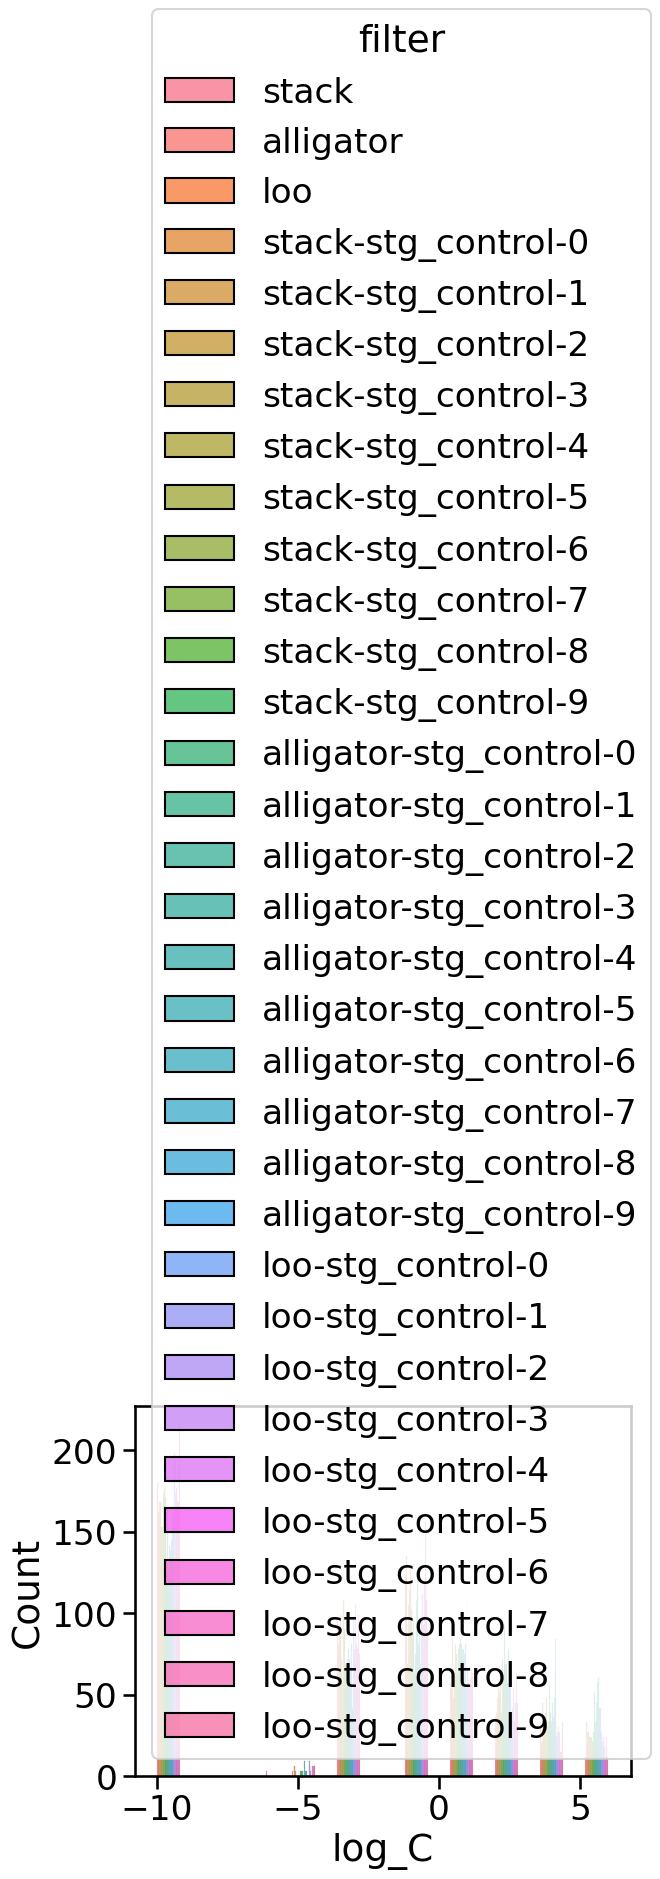

In [156]:
sns.histplot(data=merged_df, x="log_C", hue="filter", multiple="dodge")

In [157]:
scores_df.to_csv(Path(outdir) / "scores.csv")

In [163]:
torch.save({"models": all_models, "features": all_features, "outcomes": all_outcomes}, Path(outdir) / "outcomes.pt")

## Plot decoding performance

In [159]:
sns.set_context("talk", font_scale=1.5)

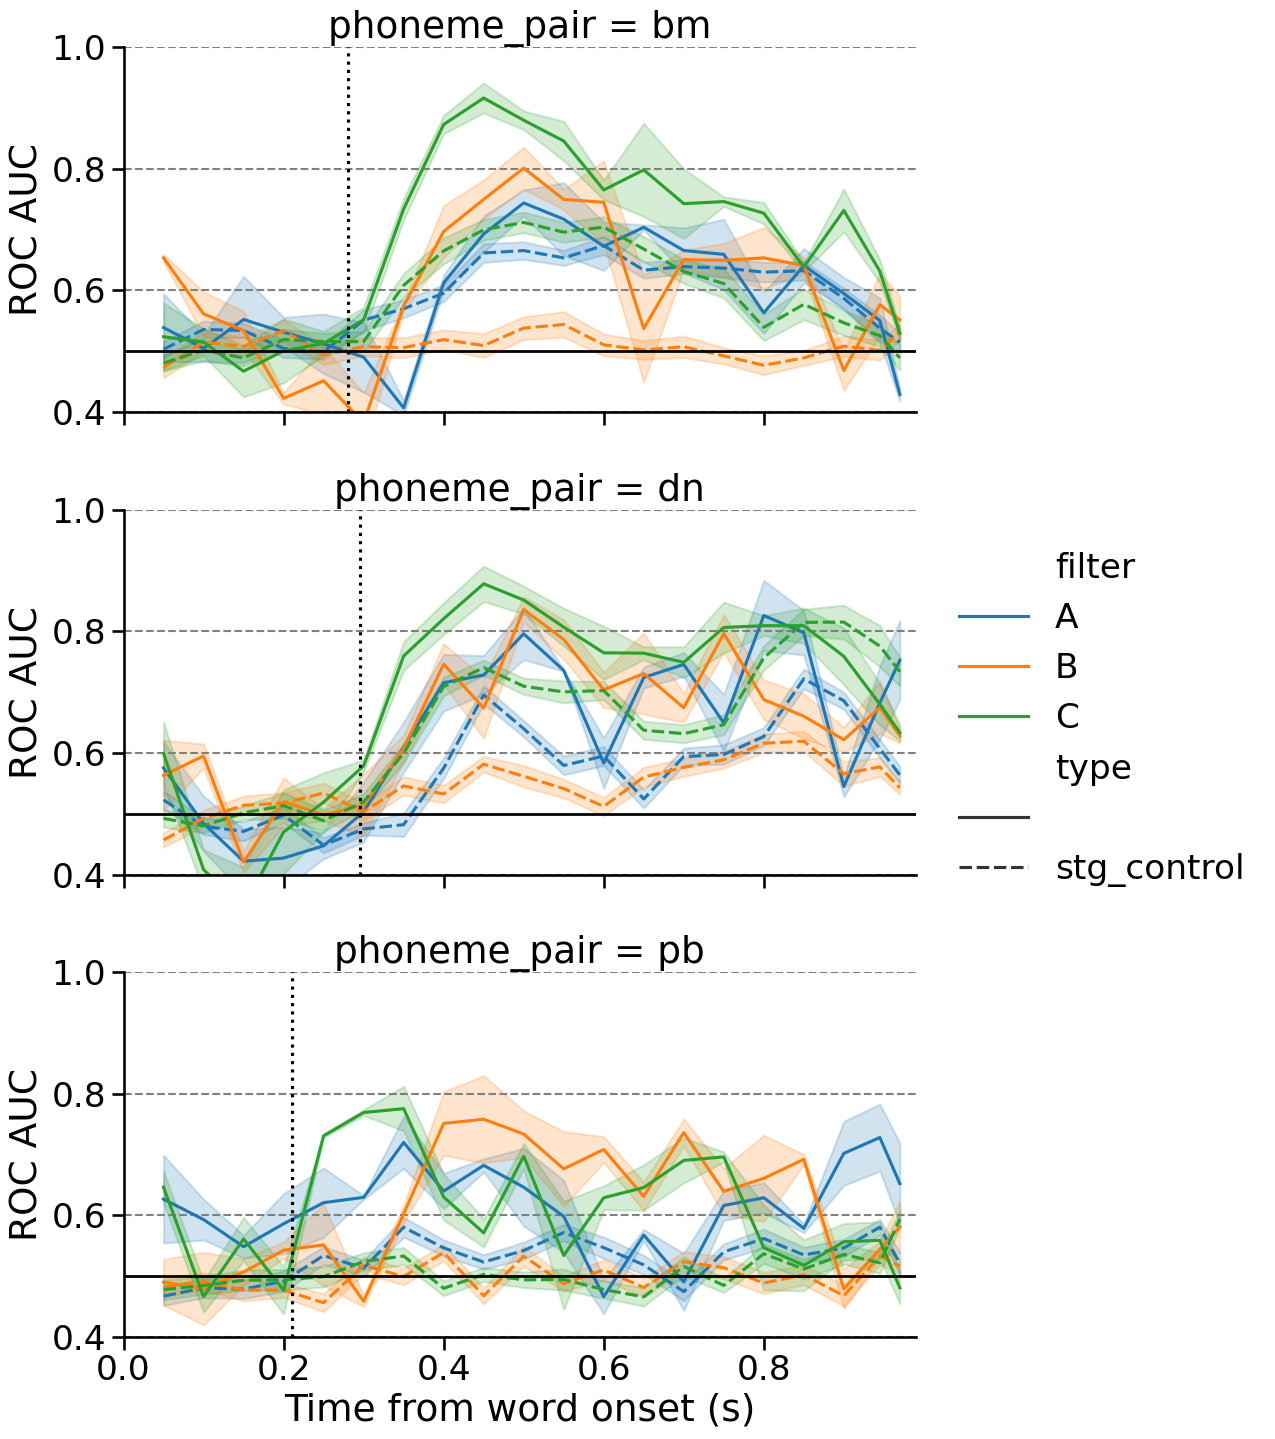

In [160]:
plot_df = scores_df.reset_index()
plot_df["filter"] = plot_df["filter"] + "-"
plot_df["type"] = plot_df["filter"].str.split("-", expand=True)[1].fillna("Main")
plot_df["filter"] = plot_df["filter"].str.split("-", expand=True)[0].map({
    "alligator": "B",
    "stack": "C",
    "loo": "A"
})
plot_df["t_center"] = plot_df.tmin + (plot_df.tmax - plot_df.tmin) / 2

row_order = sorted(plot_df.phoneme_pair.unique())
hue_order = sorted(plot_df["filter"].unique())
style_order = sorted(plot_df["type"].unique())
g = sns.relplot(data=plot_df, x="t_center", y="roc_auc",
                hue="filter", hue_order=hue_order,
                row="phoneme_pair", row_order=row_order,
                style="type", style_order=style_order,
                kind="line", errorbar="se",
                height=5, aspect=2)

for ax in g.axes.flat:
    ax.axhline(0.5, color="black", linewidth=2)
    ax.grid(visible=True, which="major", axis="y", linestyle="--", color="gray")
    ax.set_xlim((0, plot_df.tmax.max()))
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel("ROC AUC")
    ax.set_xlabel("Time from word onset (s)")
for (row, col, hue), facet_data in g.facet_data():
    phoneme_pair = row_order[row]
    ax = g.axes[row, col]
    # ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
    # ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(POD_dict[phoneme_pair], color="black", linestyle="dotted")

g.tight_layout()

## Coefficient time-courses

## Analyze outputs by acoustic step

In [103]:
odf = pd.concat({roi_filter: pd.concat(all_outcomes_i, names=["phoneme_pair", "tmin", "tmax"])
                 for roi_filter, all_outcomes_i in all_outcomes.items()},
                names=["roi_filter"])
odf

decoder_target  \
roi_filter        phoneme_pair tmin tmax fold                      
stack             bm           0.00 0.10 0    0              NaN   
                                              1              NaN   
                                              2              NaN   
                                              3              NaN   
                                              4              NaN   
...                                                          ...   
loo-stg_control-9 pb           0.95 0.99 2    139            NaN   
                                              140            NaN   
                                              141            NaN   
                                              142            NaN   
                                              143            NaN   

                                                   decoder_prediction  \
roi_filter        phoneme_pair tmin tmax fold                           
stack             bm           0.00 0.10 0    0                 False   
                                              1                  True   
                                              2                  True   
                                              3                 False   
                                              4                  True   
...                                                               ...   
loo-stg_control-9 pb           0.95 0.99 2    139                True   
                                              140               False   
                                              141                True   
                                              142               False   
                                              143                True   

                                                   decoder_proba  
roi_filter        phoneme_pair tmin tmax fold                     
stack             bm           0.00 0.10 0    0         0.471408  
                                              1         0.596515  
                                              2         0.516872  
                                              3         0.435959  
                                              4         0.533434  
...                                                          ...  
loo-stg_control-9 pb           0.95 0.99 2    139       0.504671  
                                              140       0.499749  
                                              141       0.501742  
                                              142       0.497928  
                                              143       0.501068  

[855360 rows x 3 columns]

In [104]:
all_metadata = pd.concat([epochs_i.metadata.rename_axis("epoch_idx") for epochs_i in epochs.values()],
                         names=["subject"], keys=epochs.keys())
all_metadata

wav_file  stim_number    word_end  \
subject epoch_idx                                                              
EC279   0            stimuli/2_mountains_bm_002.wav          2.0   mountains   
        1           stimuli/11_necessary_dn_004.wav         11.0   necessary   
        2          stimuli/35_penecillin_pb_011.wav         35.0  penecillin   
        3          stimuli/35_beneficial_pb_008.wav         35.0  beneficial   
        4            stimuli/11_desolate_dn_006.wav         11.0    desolate   
...                                             ...          ...         ...   
EC250   859          stimuli/2_mountains_bm_001.wav          2.0   mountains   
        860          stimuli/11_desolate_dn_007.wav         11.0    desolate   
        861          stimuli/2_mountains_bm_006.wav          2.0   mountains   
        862          stimuli/2_bountiful_bm_004.wav          2.0   bountiful   
        863        stimuli/35_penecillin_pb_010.wav         35.0  penecillin   

                     non_word phoneme_pair  morph_n                  base  \
subject epoch_idx                                                           
EC279   0           bountains           bm      2.0    2_mountains_bm_002   
        1           decessary           dn      4.0   11_necessary_dn_004   
        2          benecillin           pb     11.0  35_penecillin_pb_011   
        3          peneficial           pb      8.0  35_beneficial_pb_008   
        4            nesolate           dn      6.0    11_desolate_dn_006   
...                       ...          ...      ...                   ...   
EC250   859         bountains           bm      1.0    2_mountains_bm_001   
        860          nesolate           dn      7.0    11_desolate_dn_007   
        861         bountains           bm      6.0    2_mountains_bm_006   
        862         mountiful           bm      4.0    2_bountiful_bm_004   
        863        benecillin           pb     10.0  35_penecillin_pb_010   

                  file_format      root word_side  ... psychopyVersion  \
subject epoch_idx                                  ...                   
EC279   0                 wav  stimuli/      left  ...       2020.2.10   
        1                 wav  stimuli/     right  ...       2020.2.10   
        2                 wav  stimuli/     right  ...       2020.2.10   
        3                 wav  stimuli/     right  ...       2020.2.10   
        4                 wav  stimuli/     right  ...       2020.2.10   
...                       ...       ...       ...  ...             ...   
EC250   859               wav  stimuli/     right  ...        2020.2.9   
        860               wav  stimuli/      left  ...        2020.2.9   
        861               wav  stimuli/     right  ...        2020.2.9   
        862               wav  stimuli/     right  ...        2020.2.9   
        863               wav  stimuli/      left  ...        2020.2.9   

                    frameRate  Unnamed: 65  binned_responses  acoustic_slider  \
subject epoch_idx                                                               
EC279   0          117.641246         None                 2         7.989063   
        1          117.641246         None                 2         3.995312   
        2          117.641246         None                 3         8.017188   
        3          117.641246         None                 3         8.945312   
        4          117.641246         None                 3         9.964844   
...                       ...          ...               ...              ...   
EC250   859         59.816263         None                 1         1.425000   
        860         59.816263         None                 3         9.412500   
        861         59.816263         None                 3         9.625000   
        862         59.816263         None                 3         9.537500   
        863         59.816263         None                 3     

In [105]:
# decoder proba time series
proba_df = pd.merge(odf, all_metadata[["resampled"]], left_index=True, right_index=True, how="left", validate="1:1").reset_index()
col_order = sorted(proba_df.phoneme_pair.unique())
row_order = sorted(proba_df.roi_filter.unique())
g = sns.relplot(data=proba_df, kind="line",
                col="phoneme_pair", col_order=col_order,
                row="roi_filter", row_order=row_order,
                x="tmin", y="decoder_proba", hue="resampled", errorbar="se")

for ax in g.axes.flat:
    ax.axhline(0.5, ls="--", color="gray")
    ax.set_xlim((0, proba_df.tmax.max()))
    ax.set_ylabel("proba")
    ax.set_xlabel("Time from word onset (s)")
for (row, col, hue), facet_data in g.facet_data():
    phoneme_pair = col_order[col]
    ax = g.axes[row, col]
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(POD_dict[phoneme_pair], color="black", linestyle="dotted")

# g.savefig(Path(outdir) / "proba_by_step.pdf")

ValueError: cannot join with no overlapping index names

In [ ]:
def eval_roc_auc(rows):
    y_true = rows.decoder_target
    y_pred = rows.decoder_proba
    return roc_auc_score(y_true, y_pred)
all_metadata = pd.concat([epochs_i.metadata.rename_axis("epoch_idx") for epochs_i in epochs.values()],
                         names=["subject"], keys=epochs.keys())
roc_auc_df = pd.merge(odf, all_metadata[["resampled"]], left_index=True, right_index=True, how="left", validate="1:1") \
    .groupby(["subject", "roi_filter", "phoneme_pair", "tmin", "tmax", "resampled", "fold"]) \
    .apply(eval_roc_auc).rename("roc_auc").reset_index()

In [ ]:
col_order = sorted(roc_auc_df.phoneme_pair.unique())
row_order = sorted(roc_auc_df.roi_filter.unique())
g = sns.relplot(data=roc_auc_df, kind="line",
                col="phoneme_pair", col_order=col_order,
                row="roi_filter", row_order=row_order,
                x="tmin", y="roc_auc",
                hue="resampled", palette="coolwarm", hue_norm=CenteredNorm(vcenter=3.5),
                errorbar="se")

for ax in g.axes.flat:
    ax.axhline(0.5, ls="--", color="gray")
    ax.set_xlim((0, roc_auc_df.tmax.max()))
    ax.set_ylabel("ROC AUC")
    ax.set_xlabel("Time from word onset (s)")
for (row, col, hue), facet_data in g.facet_data():
    phoneme_pair = col_order[col]
    ax = g.axes[row, col]
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(POD_dict[phoneme_pair], color="black", linestyle="dotted")

g.savefig(Path(outdir) / "decoding_by_step.pdf")